In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3256,ham,"No, but you told me you were going, before you...",NaN,NaN,NaN
3691,ham,No i am not having not any movies in my laptop,NaN,NaN,NaN
1451,ham,Ya! when are Ì_ taking ure practical lessons? ...,NaN,NaN,NaN
4953,ham,U coming back 4 dinner rite? Dad ask me so i r...,NaN,NaN,NaN
2553,ham,ÌÏ give me some time to walk there.,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


### Data Cleaning :-


In [5]:
# The dataset has some unnamed columns which are not required for our analysis. We will drop those columns.
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
# The columns "v1" and "v2" are not descriptive. We will rename those columns to "target" and "text" respectively.
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)

In [8]:
df.sample(5)

,target,text
2508,ham,Ok...
1037,ham,"naughty little thought: 'its better to flirt, ..."
1971,ham,Enjoy ur life. . Good night
5362,ham,I'm in inside office..still filling forms.don ...
4980,ham,I said its okay. Sorry


In [9]:
#encoding the target column
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["target"] = encoder.fit_transform(df["target"])

In [10]:
df.sample(5)

,target,text
5301,0,At WHAT TIME should i come tomorrow
4094,0,I ain't answerin no phone at what is actually ...
1905,0,"There're some people by mu, I'm at the table b..."
967,0,What do u want when i come back?.a beautiful n...
5070,0,As in different styles?


In [11]:
# checking for missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
# checking duplicated values
df.duplicated().sum()

np.int64(403)

In [13]:
# removing duplicated values
df = df.drop_duplicates(keep="first")

In [14]:
df.duplicated().sum()

np.int64(0)

### EDA (Exploratory Data Analysis) :-


In [15]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

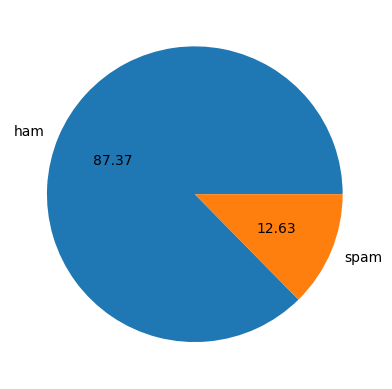

In [17]:
# visualizing the target column using pie chart
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [18]:

!pip install nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# calculating the number of characters in each message
df['num_characters'] = df['text'].apply(len)
df['num_characters']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: num_characters, Length: 5169, dtype: int64

In [20]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
# calculating the number of words in each message
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_words']

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: num_words, Length: 5169, dtype: int64

In [22]:
#  calculating the number of sentences in each message
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df['num_sentences']

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: num_sentences, Length: 5169, dtype: int64

In [23]:
# describing the new features
df[['num_words', 'num_characters', 'num_sentences']].describe()

,num_words,num_characters,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,18.455794,78.977945,1.965564
std,13.324758,58.236293,1.448541
min,1.000000,2.000000,1.000000
25%,9.000000,36.000000,1.000000
50%,15.000000,60.000000,1.000000
75%,26.000000,117.000000,2.000000
max,220.000000,910.000000,38.000000


In [24]:
# describing ham messages
df[df['target'] == 0][['num_words', 'num_characters', 'num_sentences']].describe()

,num_words,num_characters,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,17.123782,70.459256,1.820195
std,13.493970,56.358207,1.383657
min,1.000000,2.000000,1.000000
25%,8.000000,34.000000,1.000000
50%,13.000000,52.000000,1.000000
75%,22.000000,90.000000,2.000000
max,220.000000,910.000000,38.000000


In [25]:
# describing spam messages
df[df['target'] == 1][['num_words', 'num_characters', 'num_sentences']].describe()

,num_words,num_characters,num_sentences
count,653.000000,653.000000,653.000000
mean,27.667688,137.891271,2.970904
std,7.008418,30.137753,1.488425
min,2.000000,13.000000,1.000000
25%,25.000000,132.000000,2.000000
50%,29.000000,149.000000,3.000000
75%,32.000000,157.000000,4.000000
max,46.000000,224.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

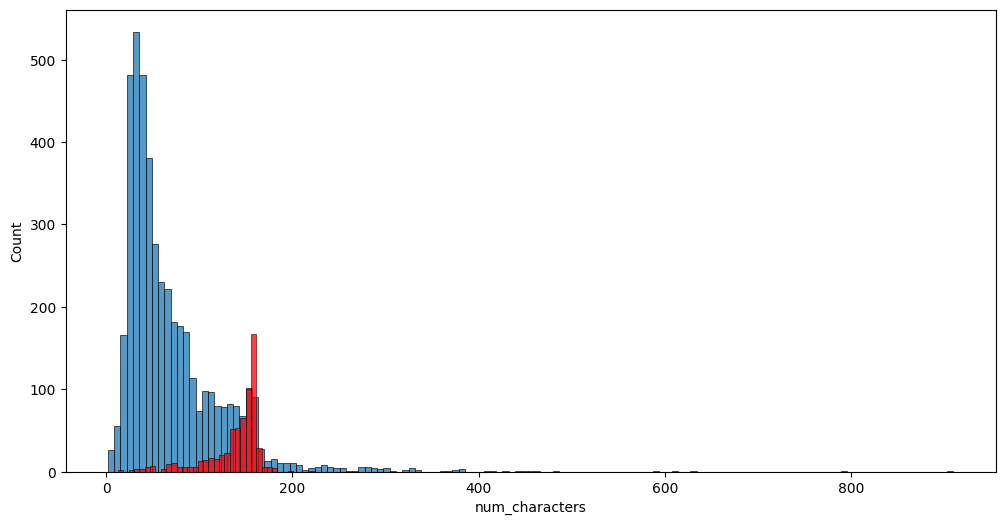

In [26]:
# visualizing the number of characters in ham and spam messages
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

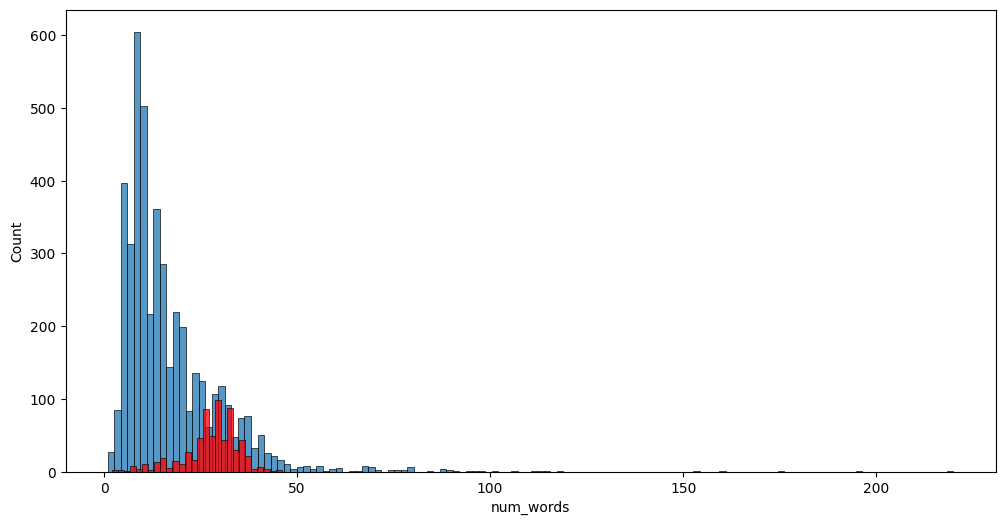

In [27]:
# visualizing the number of words in ham and spam messages
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

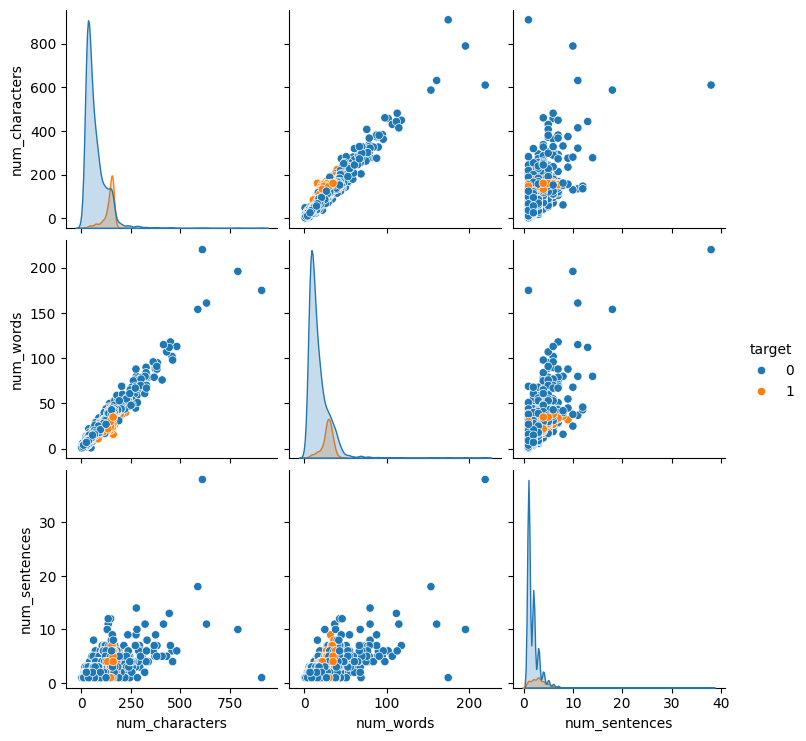

In [28]:
# visualizing a pairplot of the new features
sns.pairplot(df, hue="target")

<Axes: >

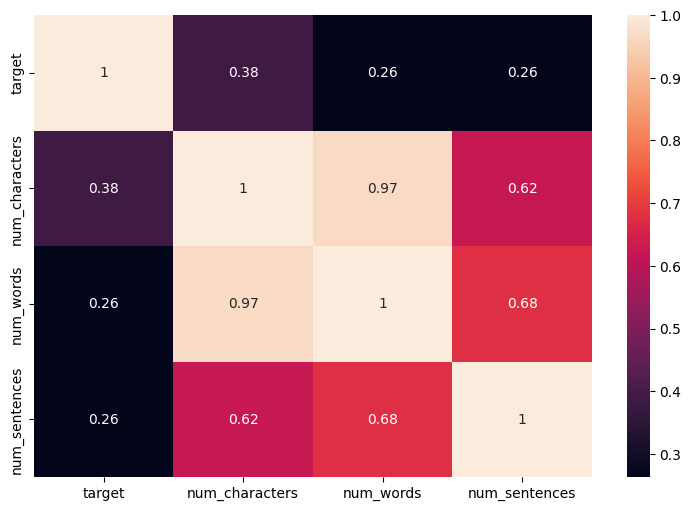

In [29]:
# visualizing the correlation between the new features
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Data Preprocessing :-

- Convert to lower case
- Tokenize the text
- Remove special characters
- Remove stop words and punctuations
- Stemming


In [30]:
# text preprocessing
import string
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
nltk.download('stopwords')


def transform_text(text):
    # converting the text to lowercase
    text = text.lower()

    # tokenizing the text (breaking the text into words)
    text = nltk.word_tokenize(text)

    # removing the special characters and only keeping the alphanumeric characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # removing the stop words and punctuation
    text = y[:]
    y.clear()
    for i in text:
        if i not in nltk.corpus.stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    # stemming the words (removing the suffixes from the words)
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
df['transformed_text'] = df['text'].apply(transform_text)

In [32]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
2608,0,Hello madam how are you ?,25,6,1,hello madam
1288,0,Happy new year to u too!,24,7,1,happi new year u
4008,0,Ha... Then we must walk to everywhere... Canno...,112,25,3,ha must walk everywher take tram cousin said w...
808,0,I am taking half day leave bec i am not well,44,11,1,take half day leav bec well
2822,0,Then u ask darren go n pick u lor... But i oso...,74,20,2,u ask darren go n pick u lor oso sian tmr haf ...


In [33]:
# installing the wordcloud library
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from wordcloud import WordCloud

In [35]:
wc = WordCloud(width=700, height=400, min_font_size=7, background_color='white')

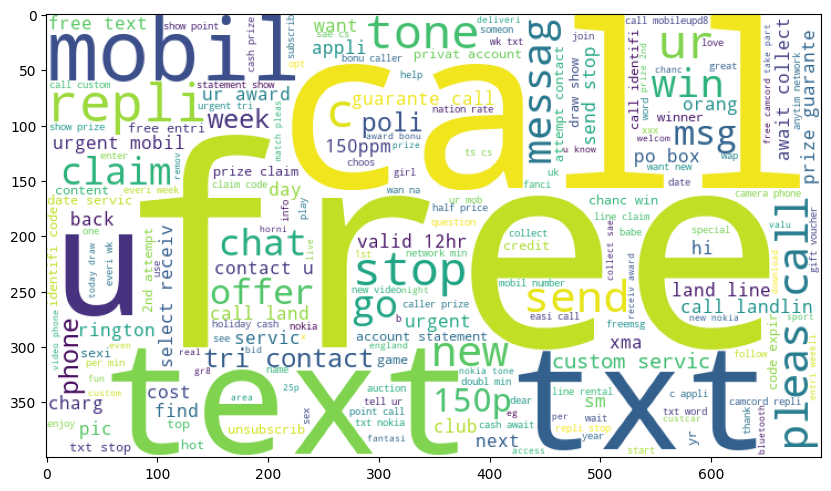

In [36]:
# generating the word cloud for spam messages
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 7))
plt.imshow(spam_wc)

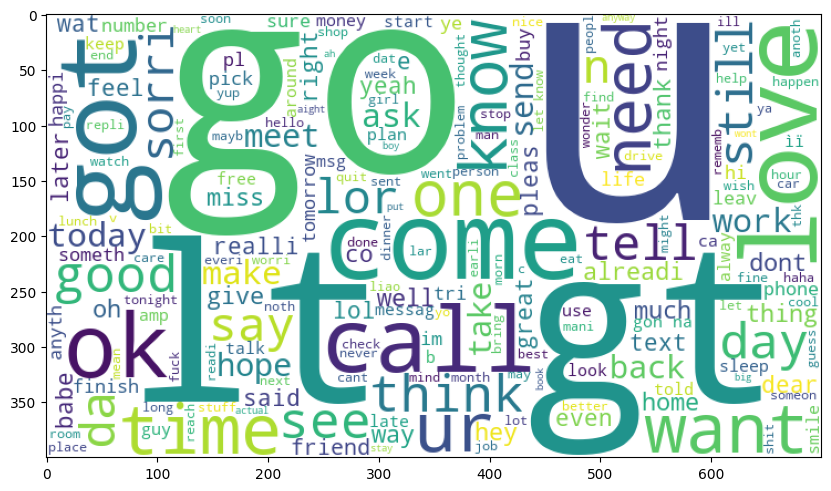

In [37]:
# generating the word cloud for ham messages
spam_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 7))
plt.imshow(spam_wc)

In [38]:
# creating a corpus of all the words in the spam messages so that we can find the most occurring words in the spam messages

spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [39]:
len(spam_corpus)

9939

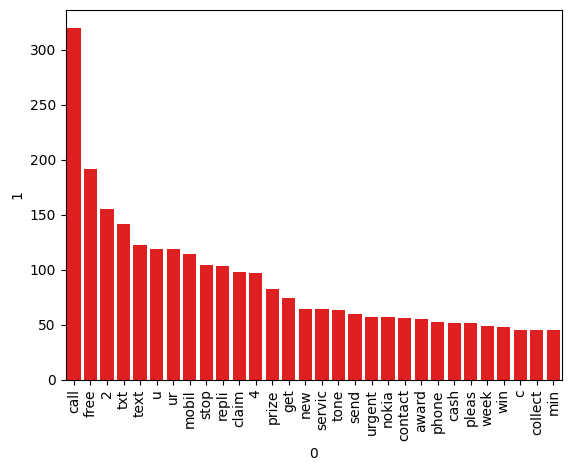

In [57]:
# for spam
from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1], color='red')
plt.xticks(rotation= 'vertical')
plt.show()

In [41]:
# creating a corpus of all the words in the ham messages so that we can find the most occurring words in the ham messages

ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [42]:
len(ham_corpus)

35404

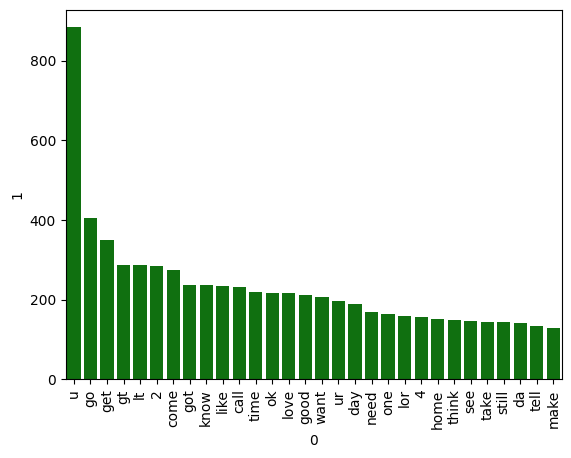

In [58]:
# for ham
sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1], color='green')
plt.xticks(rotation= 'vertical')
plt.show()

### Model Building :-


In [44]:
dfM = df.copy()

In [45]:
dfM.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [46]:
# trasnforming the text data into numerical data using count vectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv = CountVectorizer()
tfidf = TfidfTransformer()

In [47]:
X = tfidf.fit_transform(cv.fit_transform(dfM['transformed_text'])).toarray()

In [48]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 6708))

In [49]:
y = dfM['target'].values

In [50]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [51]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [52]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [53]:
mnb = MultinomialNB()
bnb = BernoulliNB()
gnb = GaussianNB()

In [54]:
gnb.fit(X_train, y_train)
y_pred_1 = gnb.predict(X_test)
print("==== Gaussian Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_1), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_1), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_1), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_1), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_1), end ="\n\n")

==== Gaussian Naive Bayes ====
Accuracy: 0.8762088974854932

Confusion Matrix:
[[793 103]
 [ 25 113]]

Precision: 0.5231481481481481

Recall: 0.8188405797101449

F1 Score: 0.6384180790960452



In [55]:
mnb.fit(X_train, y_train)
y_pred_2 = mnb.predict(X_test)
print("==== Multinomial Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_2), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_2), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_2), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_2), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_2), end ="\n\n")

==== Multinomial Naive Bayes ====
Accuracy: 0.9593810444874274

Confusion Matrix:
[[896   0]
 [ 42  96]]

Precision: 1.0

Recall: 0.6956521739130435

F1 Score: 0.8205128205128205



In [56]:
bnb.fit(X_train, y_train)
y_pred_3 = bnb.predict(X_test)
print("==== Bernoulli Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_3), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_3), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_3), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_3), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_3), end ="\n\n")

==== Bernoulli Naive Bayes ====
Accuracy: 0.9700193423597679

Confusion Matrix:
[[893   3]
 [ 28 110]]

Precision: 0.9734513274336283

Recall: 0.7971014492753623

F1 Score: 0.8764940239043825

